<a href="https://colab.research.google.com/github/RajShekhar0341/DataScience/blob/main/Sentimental_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


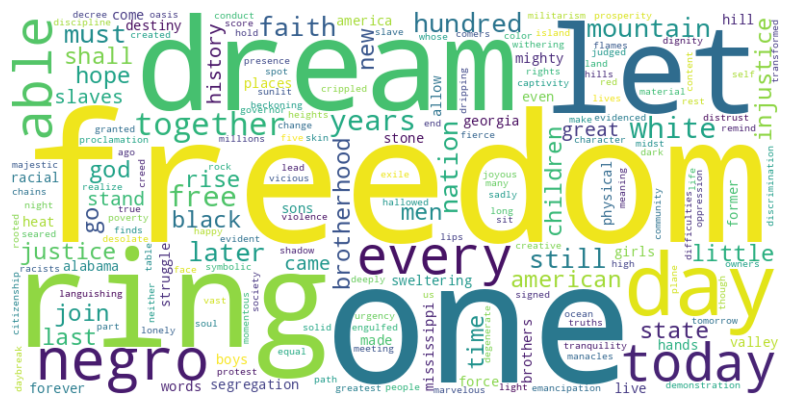

Sentiment Scores:
neg: 0.078
neu: 0.605
pos: 0.317
compound: 0.9992

Sentence 1 Sentiment Scores:
{'neg': 0.0, 'neu': 0.333, 'pos': 0.667, 'compound': 0.8402}

Sentence 2 Sentiment Scores:
{'neg': 0.34, 'neu': 0.467, 'pos': 0.193, 'compound': -0.6581}


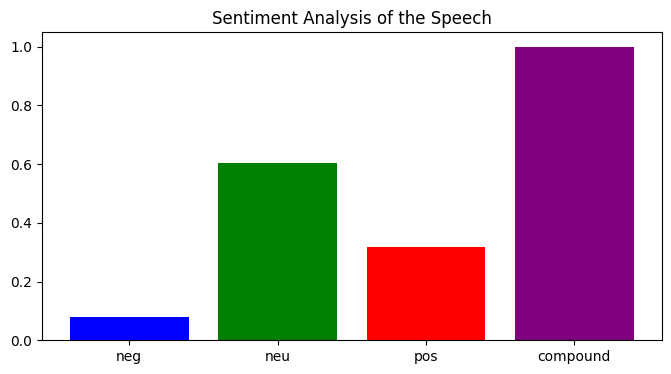

In [ ]:
# Install necessary libraries
!pip install nltk
!pip install wordcloud

# Import libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import string
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

# Download required nltk data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')

# Load the text file
with open('/content/speech.txt', 'r') as file:  # Update the path as per your Google Colab environment
    text = file.read()

# Convert text to lower case
clean_text = text.lower()

# Remove punctuation
clean_text = re.sub(r'[^\w\s]', ' ', clean_text)

# Remove digits
clean_text = re.sub(r'\d+', ' ', clean_text)

# Remove stopwords
stop_words = set(stopwords.words('english'))
clean_text_tokens = word_tokenize(clean_text)
clean_text_tokens = [word for word in clean_text_tokens if word not in stop_words and len(word) > 1]

# Rejoin tokens into a string
clean_text = ' '.join(clean_text_tokens)

# Word frequency analysis
word_freq = nltk.FreqDist(clean_text_tokens)

# Word Cloud
wordcloud = WordCloud(width = 800, height = 400, background_color ='white').generate_from_frequencies(word_freq)
plt.figure(figsize = (10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

# Sentiment Analysis using VADER
sia = SentimentIntensityAnalyzer()
sentiment_scores = sia.polarity_scores(clean_text)

# Display sentiment scores
print("Sentiment Scores:")
for key, value in sentiment_scores.items():
    print(f"{key}: {value}")

# Example sentences for sentiment analysis
sentence1 = "I love cats such a bundle of joy."
sentence2 = "I hate to see so much sadness and pain in the world still it is really good to be alive."

print("\nSentence 1 Sentiment Scores:")
print(sia.polarity_scores(sentence1))

print("\nSentence 2 Sentiment Scores:")
print(sia.polarity_scores(sentence2))

# Sentiment breakdown (VADER does not give emotions like syuzhet, so we'll focus on positive, negative, neutral, and compound)
# You can create a bar plot for visualization
sentiment_df = pd.DataFrame.from_dict(sentiment_scores, orient='index', columns=['Score']).reset_index()
sentiment_df.rename(columns={'index': 'Sentiment'}, inplace=True)

# Plot sentiment scores
plt.figure(figsize=(8, 4))
plt.bar(sentiment_df['Sentiment'], sentiment_df['Score'], color=['blue', 'green', 'red', 'purple'])
plt.title('Sentiment Analysis of the Speech')
plt.show()
